In [29]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\lenovo\Downloads\archive (7)\E-commerce Customer Behavior - Sheet1.csv")

In [10]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


In [12]:
df.shape

(350, 11)

In [13]:
df.isnull().sum()

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

In [14]:
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


In [17]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'City', 'Membership Type',
       'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied',
       'Days Since Last Purchase', 'Satisfaction Level'],
      dtype='object')

In [18]:
df.groupby("Customer ID")["Total Spend"].sum().sort_values(ascending=False).head(10)

Customer ID
110    1520.1
128    1500.1
218    1500.1
331    1500.1
188    1500.1
260    1500.1
158    1500.1
290    1500.1
409    1490.1
319    1490.1
Name: Total Spend, dtype: float64

### 1. Customer Contribution Insight
A small group of customers contributes a large portion of total revenue, showing that the business depends heavily on loyal customers.

In [21]:
df["Gender"].value_counts()

Gender
Female    175
Male      175
Name: count, dtype: int64

## Gender Insight

The dataset shows the distribution of customers across different genders. It helps us understand which gender group is more active in shopping behavior.

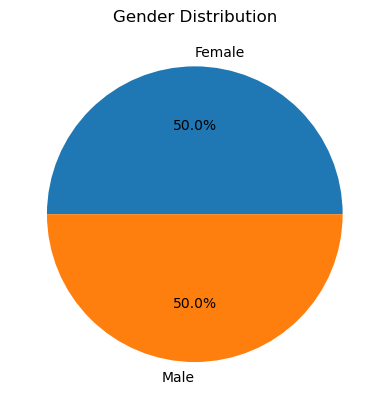

In [31]:
df["Gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Gender Distribution")
plt.ylabel("")

plt.show()

<Axes: xlabel='City'>

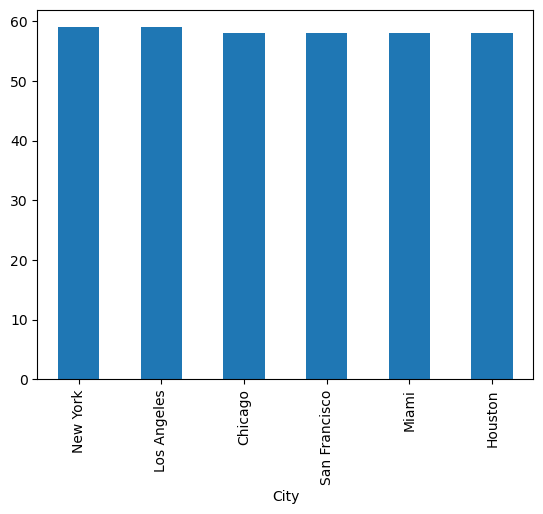

In [20]:
df["City"].value_counts().plot(kind="bar")

## City Insight

The dataset shows that customers are distributed across multiple cities. Some cities have higher customer counts compared to others, indicating uneven geographical distribution of users.

In [22]:
df["Membership Type"].value_counts()

Membership Type
Gold      117
Silver    117
Bronze    116
Name: count, dtype: int64

Membership Type Preference

Most customers prefer a specific membership type, showing strong preference patterns in subscription plans.

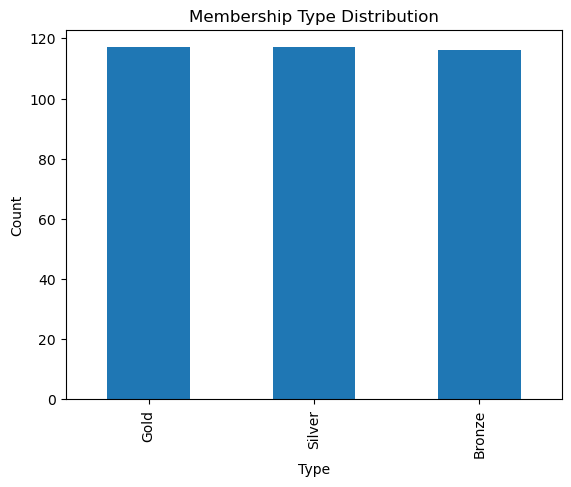

In [32]:
df["Membership Type"].value_counts().plot(kind="bar")

plt.title("Membership Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

In [23]:
df["Total Spend"].describe()

count     350.000000
mean      845.381714
std       362.058695
min       410.800000
25%       502.000000
50%       775.200000
75%      1160.600000
max      1520.100000
Name: Total Spend, dtype: float64

Spending Behavior Variation

Customer spending varies significantly, indicating presence of both low-value and high-value customers.

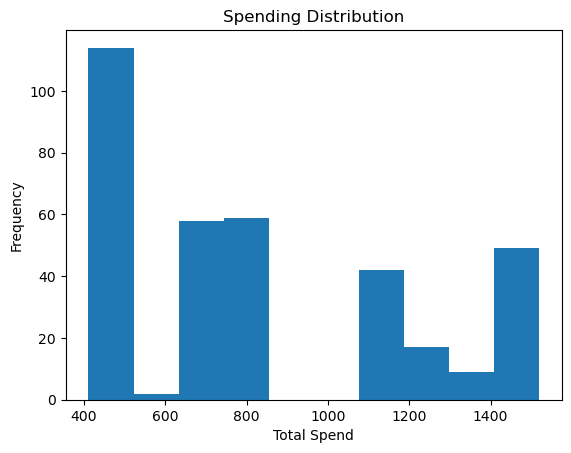

In [33]:
df["Total Spend"].plot(kind="hist", bins=10)

plt.title("Spending Distribution")
plt.xlabel("Total Spend")
plt.ylabel("Frequency")

plt.show()

In [24]:
df.groupby("Age")["Total Spend"].mean()

Age
26     689.488889
27     710.820000
28    1492.183333
29    1290.218182
30    1325.645833
31    1144.600000
32     805.451515
33     820.640000
34     791.045833
35     800.088000
36     500.912000
37     432.050000
38     444.233333
41     484.416667
42     518.716667
43     507.950000
Name: Total Spend, dtype: float64

Age vs Spending Behavior

Spending behavior changes across age groups, showing age influences purchasing power.

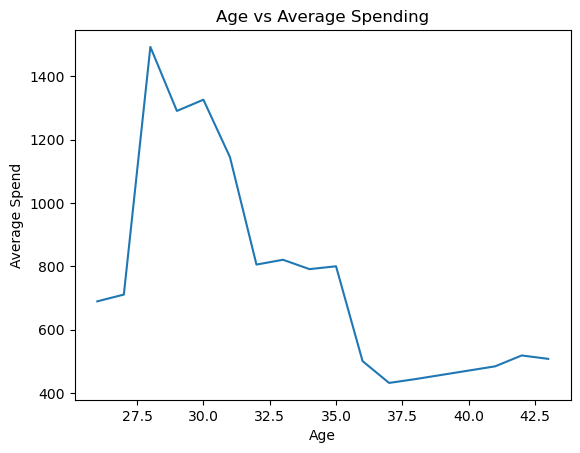

In [34]:
df.groupby("Age")["Total Spend"].mean().plot(kind="line")

plt.title("Age vs Average Spending")
plt.xlabel("Age")
plt.ylabel("Average Spend")

plt.show()

In [25]:
df["Discount Applied"].value_counts()

Discount Applied
True     175
False    175
Name: count, dtype: int64

Discount Usage Impact

A large number of customers use discounts, indicating that price incentives strongly influence purchase decisions.

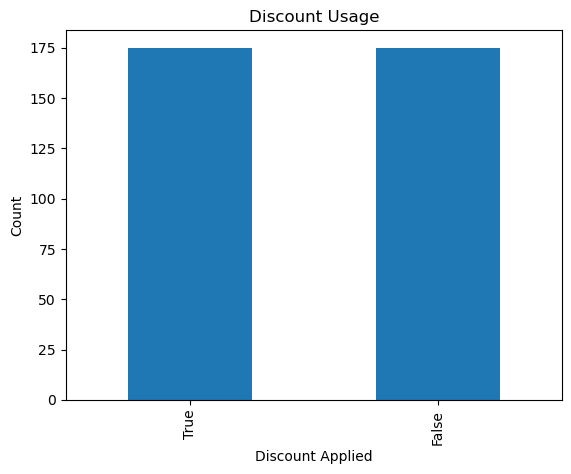

In [35]:
df["Discount Applied"].value_counts().plot(kind="bar")

plt.title("Discount Usage")
plt.xlabel("Discount Applied")
plt.ylabel("Count")

plt.show()

In [26]:
df["Satisfaction Level"].value_counts()

Satisfaction Level
Satisfied      125
Unsatisfied    116
Neutral        107
Name: count, dtype: int64

Customer Satisfaction Level

Most customers report medium to high satisfaction levels, indicating generally positive customer experience.

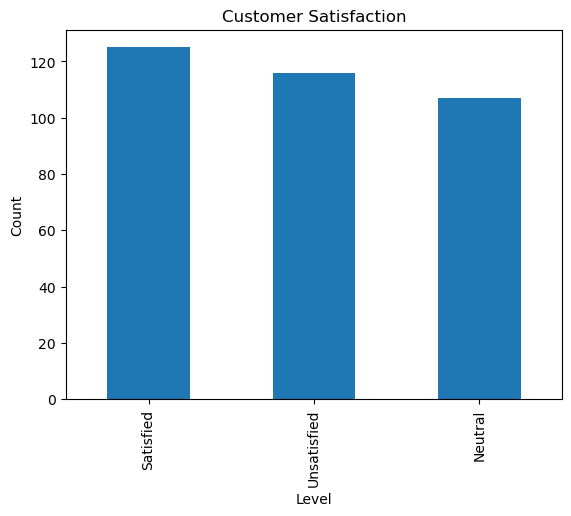

In [36]:
df["Satisfaction Level"].value_counts().plot(kind="bar")

plt.title("Customer Satisfaction")
plt.xlabel("Level")
plt.ylabel("Count")

plt.show()

In [27]:
df["Items Purchased"].describe()

count    350.000000
mean      12.600000
std        4.155984
min        7.000000
25%        9.000000
50%       12.000000
75%       15.000000
max       21.000000
Name: Items Purchased, dtype: float64

Purchase Behavior Variation

Customers show different purchasing patterns in terms of items bought, indicating varied shopping behavior.

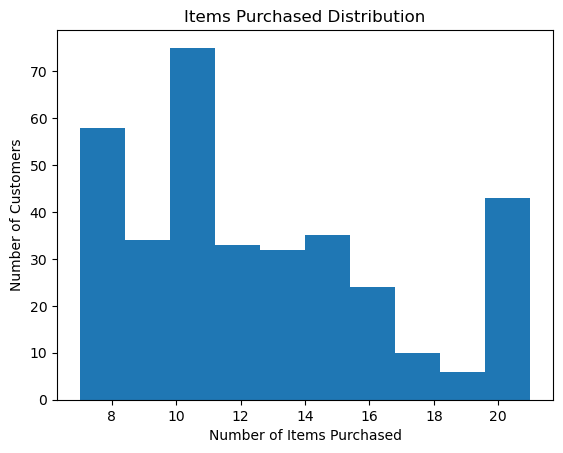

In [37]:
df["Items Purchased"].plot(kind="hist", bins=10)

plt.title("Items Purchased Distribution")
plt.xlabel("Number of Items Purchased")
plt.ylabel("Number of Customers")

plt.show()

In [28]:

df["Days Since Last Purchase"].describe()


count    350.000000
mean      26.588571
std       13.440813
min        9.000000
25%       15.000000
50%       23.000000
75%       38.000000
max       63.000000
Name: Days Since Last Purchase, dtype: float64

Customer Engagement Pattern

Some customers are highly active while others are inactive, showing differences in engagement and retention.